## Load the libraries we need

Here we import the main Python libraries we will use in this project.

- **pandas** for handling normal tabular data
- **geopandas** for spatial data (maps, points, polygons)
- **matplotlib** for quick visual plots
- **json** for reading json files
- **shapely.wkt** to onvert geometry stores as text into real geometry objects

In [25]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import json
from shapely import wkt

# skoler.csv dataset

## Load the schools dataset

Here we load the 'skoler.csv' file wich contains information about all schools in Copenhagen.

The dataset already includes a geometry column ('wkb_geometry'), but it is stored as text. Later we will convert that column into acutal spatial geometry.

For now we just load the dataset and inspect the first few rows to understand the structure.

In [4]:
schools_df = pd.read_csv("../data/raw/skoler.csv", encoding="latin1")
schools_df.head()

,FID,y_koordinat,x_koordinat,vejkode,kommunekode,omraade,navn,vejnavn,vejnummer,postnummer,bby,hjemmesideadresse,bydelnavn,bydelsid,wkb_geometry
0,skoler.1,6175474.01,724837.01,8252,101,Indre By-Østerbro,Den Classenske Legatskole,Vester Voldgade,98,1552,København V,http://www.dcl.kk.dk,Indre By,1,POINT (12.57572806609185 55.67291623323177)
1,skoler.2,6177008.01,725231.01,7280,101,Indre By-Østerbro,Sølvgades Skole,Sølvgade,16,1307,København K,http://www.soel.kk.dk,Indre By,1,POINT (12.58323934936467 55.68649040450764)
2,skoler.3,6177471.01,725396.01,8612,101,Indre By-Østerbro,Nyboder Skole,Øster Voldgade,15,1350,København K,http://www.nyboderskole.kk.dk,Indre By,1,POINT (12.586239078060993 55.69056593267992)
3,skoler.4,6177675.01,724862.01,8588,101,Indre By-Østerbro,Øster Farimagsgades Skole,Øster Farimagsgade,40,2100,København Ø,http://www.oef.kk.dk,Indre By,1,POINT (12.577928570337939 55.69264299706235)
4,skoler.5,6175663.01,726146.01,5612,101,Indre By-Østerbro,Christianshavns Skole,Prinsessegade,45,1422,København K,http://www.chr.kk.dk,Christianshavn,2,POINT (12.596655758536535 55.67400357485248)


## Check the column names

Before doing anything else, we want to see what columns exist in the dataset.

This helps us understand which columns contains coordinates, which columns contains names and attributes and which columns contains the geometry.

In [5]:
schools_df.columns

Index(['FID', 'y_koordinat', 'x_koordinat', 'vejkode', 'kommunekode',
       'omraade', 'navn', 'vejnavn', 'vejnummer', 'postnummer', 'bby',
       'hjemmesideadresse', 'bydelnavn', 'bydelsid', 'wkb_geometry'],
      dtype='object')

## Inspect the dataset structure

Here we check the dataset structure, which tells us how many rows there are, hich data types each column has and if there is any values.

In [6]:
schools_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   FID                58 non-null     object 
 1   y_koordinat        58 non-null     float64
 2   x_koordinat        58 non-null     float64
 3   vejkode            58 non-null     int64  
 4   kommunekode        58 non-null     int64  
 5   omraade            58 non-null     object 
 6   navn               58 non-null     object 
 7   vejnavn            58 non-null     object 
 8   vejnummer          58 non-null     object 
 9   postnummer         58 non-null     int64  
 10  bby                58 non-null     object 
 11  hjemmesideadresse  58 non-null     object 
 12  bydelnavn          58 non-null     object 
 13  bydelsid           58 non-null     int64  
 14  wkb_geometry       58 non-null     object 
dtypes: float64(2), int64(4), object(9)
memory usage: 6.9+ KB


## Check for missing values

Here we check if any columns contains missing values.

This is important because missing coordinates or geometry could case problems later when working with spatial data.

In [26]:
schools_df.isna().sum()

FID                  0
y_koordinat          0
x_koordinat          0
vejkode              0
kommunekode          0
omraade              0
navn                 0
vejnavn              0
vejnummer            0
postnummer           0
bby                  0
hjemmesideadresse    0
bydelnavn            0
bydelsid             0
wkb_geometry         0
geometry             0
dtype: int64

## Convert the geometry column

The dataset contains a column calles 'wbk_geometry', but it is stored as text.

Here we convert that text into real geometry objects using shapely do GeoPandas can understand it as spatial data.

In [10]:
schools_df["geometry"] = schools_df["wkb_geometry"].apply(wkt.loads)

## Create a GeoDataFrame

Now we convert the pandas dataframe into a GeoDataFrame.

This allows us to work with the data spatially (plot maps, do joins etc.)

At this point the coordinate system is set to EPSG:4326, which is the standard longitude/latitude CRS. We will look at this a bit later.

In [12]:
schools = gpd.GeoDataFrame(schools_df, geometry="geometry", crs="EPSG:4326")

In [13]:
schools.head()

,FID,y_koordinat,x_koordinat,vejkode,kommunekode,omraade,navn,vejnavn,vejnummer,postnummer,bby,hjemmesideadresse,bydelnavn,bydelsid,wkb_geometry,geometry
0,skoler.1,6175474.01,724837.01,8252,101,Indre By-Østerbro,Den Classenske Legatskole,Vester Voldgade,98,1552,København V,http://www.dcl.kk.dk,Indre By,1,POINT (12.57572806609185 55.67291623323177),POINT (12.57573 55.67292)
1,skoler.2,6177008.01,725231.01,7280,101,Indre By-Østerbro,Sølvgades Skole,Sølvgade,16,1307,København K,http://www.soel.kk.dk,Indre By,1,POINT (12.58323934936467 55.68649040450764),POINT (12.58324 55.68649)
2,skoler.3,6177471.01,725396.01,8612,101,Indre By-Østerbro,Nyboder Skole,Øster Voldgade,15,1350,København K,http://www.nyboderskole.kk.dk,Indre By,1,POINT (12.586239078060993 55.69056593267992),POINT (12.58624 55.69057)
3,skoler.4,6177675.01,724862.01,8588,101,Indre By-Østerbro,Øster Farimagsgades Skole,Øster Farimagsgade,40,2100,København Ø,http://www.oef.kk.dk,Indre By,1,POINT (12.577928570337939 55.69264299706235),POINT (12.57793 55.69264)
4,skoler.5,6175663.01,726146.01,5612,101,Indre By-Østerbro,Christianshavns Skole,Prinsessegade,45,1422,København K,http://www.chr.kk.dk,Christianshavn,2,POINT (12.596655758536535 55.67400357485248),POINT (12.59666 55.67400)


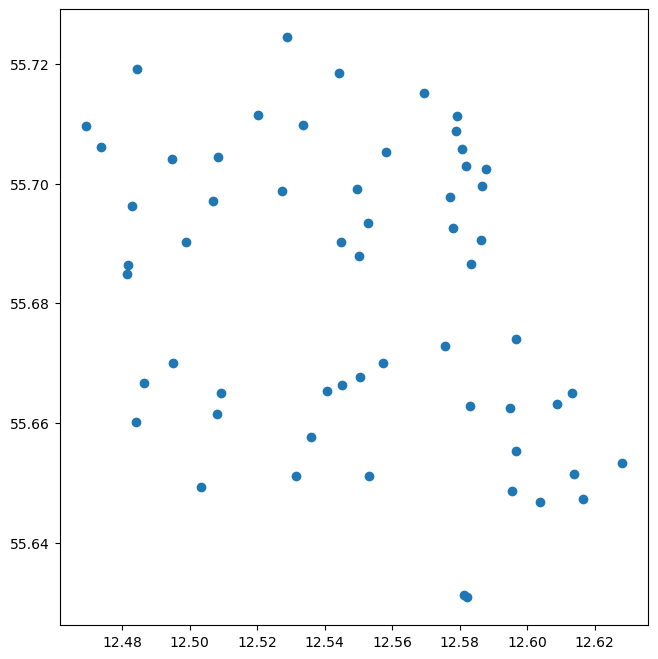

In [14]:
schools.plot(figsize=(8,8))
plt.show()

In [15]:
schools.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [16]:
schools.geometry.head()

0    POINT (12.57573 55.67292)
1    POINT (12.58324 55.68649)
2    POINT (12.58624 55.69057)
3    POINT (12.57793 55.69264)
4    POINT (12.59666 55.67400)
Name: geometry, dtype: geometry

In [17]:
schools = schools.to_crs(25832)

## Convert to a projected CRS

The dataset is currently in latitude/longitude.

For spatial analysis and distance calclations it is better to use a projected CRS in meters.

Since we look at Copenhagen, we convert the data to EPSG:25832.

In [18]:
schools.crs

<Projected CRS: EPSG:25832>
Name: ETRS89 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Europe between 6°E and 12°E: Austria; Belgium; Denmark - onshore and offshore; Germany - onshore and offshore; Norway including - onshore and offshore; Spain - offshore.
- bounds: (6.0, 38.76, 12.01, 84.33)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [19]:
schools.geometry.head()

0    POINT (724837.010 6175474.014)
1    POINT (725231.010 6177008.014)
2    POINT (725396.010 6177471.014)
3    POINT (724862.010 6177675.014)
4    POINT (726146.010 6175663.014)
Name: geometry, dtype: geometry

## Create clean x and y coordinate columns

Here we extract the coordinates directly from the geometry.

This ensures that the x and y valyes match the actual spatial geometry used by GeoPandas.

In [21]:
schools["x"] = schools.geometry.x
schools["y"] = schools.geometry.y

In [22]:
schools[["navn", "x", "y"]].head()

,navn,x,y
0,Den Classenske Legatskole,724837.009809,6.175474e+06
1,Sølvgades Skole,725231.009808,6.177008e+06
2,Nyboder Skole,725396.009808,6.177471e+06
3,Øster Farimagsgades Skole,724862.009809,6.177675e+06
4,Christianshavns Skole,726146.009807,6.175663e+06


In [24]:
schools = schools.drop(columns=["wkb_geometry"])

In [29]:
schools = schools.drop(columns=["FID"])

## Save the cleaned spatial layer for later use

Finally we save the processed schools dataset as GeoPackage.

This allows us to easily reuse the cleaned spatial layer later in the research project.

In [30]:
schools.to_file(
    "../data/processed/core_layers.gpkg",
    layer="schools",
    driver="GPKG"
)

# Adresser til brug af skoledistrikter.xlsx

## Load and inspect the school district address dataset

Here we load the address dataset that will later be used to build approximate school district plygons.

First we inspect the columns and data structre to understand which columns identifies the school district, whether geometry is included already and whether coordinates are stores a x and y columns or as text geometry.

In [37]:
addresses_df = pd.read_excel("../data/raw/Adresser til brug af skoledistrikter i KK 2026_02_19.xlsx")
addresses_df.head()

,Koerselsdato,Kommunekode,Kommunenavn,Adresse,Vejkode,Vejnavn,Husnr,Husnummer,Husbogstav,Stednavn,...,Skoledistriktsnr,Skoledistriktsnr_3_cifre,Skoledistriktsnavn,Socialdistriktsnavn,Sognekode,Sognenavn,GIS_koor_X,GIS_koor_Y,Longitude,Latitude
0,2026-02-19,101,København,A-Vej 13,286,A-Vej,13,13,NaN,NaN,...,281053,853,Nordøstamager Skole,Amager,7082,Vor Frelsers,728901.86,6176142.36,12.640786,55.677011
1,2026-02-19,101,København,A.C. Meyers Vænge 1,4734,A.C. Meyers Vænge,1,1,NaN,NaN,...,281060,860,Sluseholmen Skole,Valby-Vesterbro-Kgs. Enghave,9165,Sydhavn,722956.55,6173122.88,12.543978,55.652697
2,2026-02-19,101,København,A.C. Meyers Vænge 2,4734,A.C. Meyers Vænge,2,2,NaN,NaN,...,281060,860,Sluseholmen Skole,Valby-Vesterbro-Kgs. Enghave,9165,Sydhavn,722940.54,6173165.25,12.543759,55.653085
3,2026-02-19,101,København,A.C. Meyers Vænge 3,4734,A.C. Meyers Vænge,3,3,NaN,NaN,...,281060,860,Sluseholmen Skole,Valby-Vesterbro-Kgs. Enghave,9165,Sydhavn,722950.72,6173111.30,12.543876,55.652596
4,2026-02-19,101,København,A.C. Meyers Vænge 4,4734,A.C. Meyers Vænge,4,4,NaN,NaN,...,281060,860,Sluseholmen Skole,Valby-Vesterbro-Kgs. Enghave,9165,Sydhavn,722928.31,6173172.15,12.543570,55.653152


In [38]:
addresses_df.columns

Index(['Koerselsdato', 'Kommunekode', 'Kommunenavn', 'Adresse', 'Vejkode',
       'Vejnavn', 'Husnr', 'Husnummer', 'Husbogstav', 'Stednavn', 'Postnr',
       'Postdistrikt', 'Karrenr', 'Rodenr', 'Rodenavn', 'Lokaludvalgsnr',
       'Lokaludvalgsnavn', 'Bydelsnr', 'Bydelsnavn', 'Omraadenavn',
       'Skoledistriktsnr', 'Skoledistriktsnr_3_cifre', 'Skoledistriktsnavn',
       'Socialdistriktsnavn', 'Sognekode', 'Sognenavn', 'GIS_koor_X',
       'GIS_koor_Y', 'Longitude', 'Latitude'],
      dtype='object')

In [39]:
addresses_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85084 entries, 0 to 85083
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Koerselsdato              85084 non-null  datetime64[ns]
 1   Kommunekode               85084 non-null  int64         
 2   Kommunenavn               85084 non-null  object        
 3   Adresse                   85084 non-null  object        
 4   Vejkode                   85084 non-null  int64         
 5   Vejnavn                   85084 non-null  object        
 6   Husnr                     85084 non-null  object        
 7   Husnummer                 85084 non-null  int64         
 8   Husbogstav                16276 non-null  object        
 9   Stednavn                  3307 non-null   object        
 10  Postnr                    85084 non-null  int64         
 11  Postdistrikt              85084 non-null  object        
 12  Karrenr           

In [40]:
addresses_df.isna().sum()

Koerselsdato                    0
Kommunekode                     0
Kommunenavn                     0
Adresse                         0
Vejkode                         0
Vejnavn                         0
Husnr                           0
Husnummer                       0
Husbogstav                  68808
Stednavn                    81777
Postnr                          0
Postdistrikt                    0
Karrenr                       144
Rodenr                          0
Rodenavn                        0
Lokaludvalgsnr                  0
Lokaludvalgsnavn                0
Bydelsnr                        0
Bydelsnavn                      0
Omraadenavn                     0
Skoledistriktsnr                0
Skoledistriktsnr_3_cifre        0
Skoledistriktsnavn              0
Socialdistriktsnavn             0
Sognekode                       0
Sognenavn                       0
GIS_koor_X                     33
GIS_koor_Y                     33
Longitude                      33
Latitude      

## Remove rows without coordinates

A small number of rows are missing spatial coordinates.

Since the coordinates are required to create point geometry, these rows are removed before converting the dataset into a GeoDataFrame.

In [41]:
addresses_df = addresses_df.dropna(subset=["GIS_koor_X", "GIS_koor_Y"])

In [44]:
addresses_df[["GIS_koor_X", "GIS_koor_Y"]].isna().sum()

GIS_koor_X    0
GIS_koor_Y    0
dtype: int64

In [45]:
addresses = gpd.GeoDataFrame(
    addresses_df,
    geometry=gpd.points_from_xy(addresses_df["GIS_koor_X"], addresses_df["GIS_koor_Y"]),
    crs="EPSG:25832"
)

In [46]:
addresses.geometry.head()

0    POINT (728901.860 6176142.360)
1    POINT (722956.550 6173122.880)
2    POINT (722940.540 6173165.250)
3    POINT (722950.720 6173111.300)
4    POINT (722928.310 6173172.150)
Name: geometry, dtype: geometry

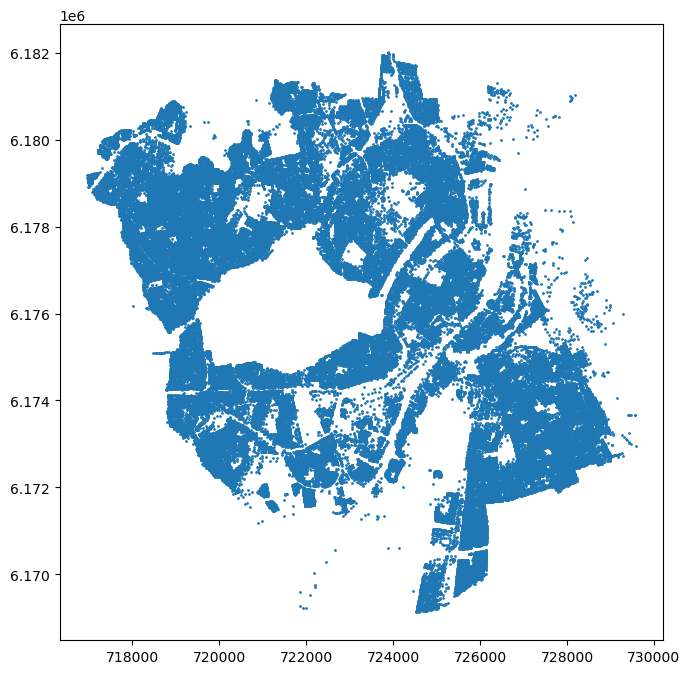

In [49]:
addresses.plot(markersize=1, figsize=(8,8))
plt.show()

## Keep only the usefull columns

The raw address dataset contains many administrative columns, that we dont need.

Here we keep only the columns that are relevant for identifying addresses, school districts and spatial locations.

In [50]:
addresses = addresses[
    [
        "Adresse",
        "Vejnavn",
        "Husnummer",
        "Postnr",
        "Bydelsnavn",
        "Skoledistriktsnr",
        "Skoledistriktsnavn",
        "GIS_koor_X",
        "GIS_koor_Y",
        "geometry"
    ]
]

In [51]:
addresses["Skoledistriktsnr"].nunique()

57

In [54]:
addresses["Skoledistriktsnavn"].value_counts().head()

Skoledistriktsnavn
Distrikt Ørestad             3663
Dyvekeskolen                 3471
Damhusengens Skole           2867
Den Classenske Legatskole    2851
Kirsebærhavens Skole         2665
Name: count, dtype: int64

In [55]:
addresses.groupby("Skoledistriktsnr")["Skoledistriktsnavn"].nunique()

Skoledistriktsnr
101001    1
101003    1
101005    1
101007    1
101008    1
101011    1
101012    1
101015    1
101017    1
101019    1
101020    1
101021    1
101022    1
101023    1
101029    1
101030    1
101034    1
101035    1
101039    1
101041    1
101042    1
101043    1
101045    1
101047    1
101049    1
101050    1
101051    1
101053    1
101055    1
101058    1
101059    1
101060    1
101062    1
101063    1
101064    1
101069    1
101070    1
101074    1
101075    1
101076    1
101138    1
101151    1
101157    1
101174    1
101175    1
101537    1
101540    1
101572    1
101586    1
280129    1
280425    1
280825    1
281053    1
281060    1
281474    1
281980    1
281981    1
Name: Skoledistriktsnavn, dtype: int64

## Save the vleaned address points

Here we save the cleaned adress dataset as a spatial layer in the GeoPackage.

This layer will later be used to build the approximate school district polygons.

In [56]:
addresses.to_file(
    "../data/processed/core_layers.gpkg",
    layer="district_addresses",
    driver="GPKG"
)